# Введение #

В мире глубокого обучения есть не только полносвязные (Dense) слои. Существуют десятки видов слоёв, которые можно добавить в модель. (Попробуйте просмотреть [документацию Keras](https://www.tensorflow.org/api_docs/python/tf/keras/layers/) для ознакомления!) Некоторые из них, как полносвязные слои, определяют связи между нейронами, а другие могут выполнять предобработку или преобразования иного рода.

В этом уроке мы узнаем о двух видах специальных слоёв, которые сами по себе не содержат нейронов, но добавляют функциональность, способную в ряде случаев улучшить модель. Оба широко используются в современных архитектурах.

# Dropout (Исключение) #

Первый из них — это «слой dropout», который помогает бороться с переобучением.

В прошлом уроке мы говорили о том, что переобучение вызвано тем, что сеть выучивает ложные закономерности в обучающих данных. Чтобы распознавать эти ложные закономерности, сеть часто полагается на очень специфические комбинации весов — своего рода «заговор» весов. Будучи столь специфичными, такие комбинации, как правило, хрупки: удалите одну — и «заговор» рушится.

На этой идее и основан **dropout**. Чтобы разрушить такие «заговоры», мы на каждом шаге обучения случайным образом *отключаем* некоторую долю входных единиц слоя, что значительно затрудняет сети возможность выучить те самые ложные закономерности в обучающих данных. Вместо этого ей приходится искать широкие, общие закономерности, чьи весовые паттерны, как правило, более устойчивы.

<figure style="padding: 1em;">
<img src="https://storage.googleapis.com/kaggle-media/learn/images/a86utxY.gif" width="600" alt="Анимация сети, циклически проходящей через различные случайные конфигурации dropout.">
<figcaption style="textalign: center; font-style: italic"><center>Здесь dropout в 50% добавлен между двумя скрытыми слоями.</center></figcaption>
</figure>

Можно также рассматривать dropout как создание своего рода *ансамбля* сетей. Предсказания будут делаться не одной большой сетью, а комитетом из меньших сетей. Отдельные члены комитета склонны совершать ошибки разного рода, но при этом часто оказываются правы одновременно, что делает комитет в целом лучше любого отдельного участника. (Если вы знакомы со случайным лесом как с ансамблем решающих деревьев — идея та же.)

## Добавление Dropout ##

В Keras аргумент `rate` слоя Dropout определяет, какой процент входных единиц следует отключить. Размещайте слой `Dropout` непосредственно перед тем слоем, к которому хотите применить dropout:

```
keras.Sequential([
    # ...
    layers.Dropout(rate=0.3), # применяет 30% dropout к следующему слою
    layers.Dense(16),
    # ...
])
```

# Пакетная нормализация (Batch Normalization) #

Следующий специальный слой, который мы рассмотрим, выполняет «пакетную нормализацию» (или «batchnorm»). Она может помочь исправить медленное или нестабильное обучение.

В нейронных сетях, как правило, рекомендуется приводить все данные к единому масштабу, например с помощью [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) или [`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) из библиотеки scikit-learn. Причина в том, что стохастический градиентный спуск (SGD) сдвигает веса сети пропорционально тому, насколько велика активация, порождаемая данными. Признаки, которые обычно порождают активации сильно различающегося размера, могут приводить к нестабильному поведению при обучении.

Итак, если нормализация данных перед подачей в сеть полезна, то, возможно, нормализация внутри сети была бы ещё лучше! На самом деле существует специальный вид слоя, который может это делать, — **слой пакетной нормализации**. Слой пакетной нормализации обрабатывает каждый поступающий мини-батч: сначала нормализует батч по его собственному среднему и стандартному отклонению, а затем помещает данные в новый масштаб с помощью двух обучаемых параметров перемасштабирования. По сути, BatchNorm выполняет своего рода согласованное перемасштабирование своих входных данных.

Чаще всего BatchNorm добавляется как вспомогательное средство для процесса оптимизации (хотя иногда он также может улучшить качество предсказаний). Модели с BatchNorm обычно требуют меньше эпох для завершения обучения. Более того, BatchNorm может устранять различные проблемы, из-за которых обучение может «застрять». Рекомендуется добавлять пакетную нормализацию в ваши модели, особенно если у вас возникают трудности во время обучения.

## Добавление пакетной нормализации ##

Кажется, что пакетную нормализацию можно использовать практически в любой точке сети. Её можно разместить после слоя...

```
layers.Dense(16, activation='relu'),
layers.BatchNormalization(),
```

... или между слоем и его функцией активации:

```
layers.Dense(16),
layers.BatchNormalization(),
layers.Activation('relu'),
```

А если добавить её в качестве первого слоя сети, она может действовать как своего рода адаптивный препроцессор, заменяя, например, `StandardScaler` из Sci-Kit Learn.

# Пример — Использование Dropout и пакетной нормализации #

Давайте продолжим разработку модели *Red Wine*. Теперь мы ещё больше увеличим ёмкость сети, но добавим dropout для контроля переобучения и пакетную нормализацию для ускорения оптимизации. На этот раз мы также откажемся от стандартизации данных, чтобы продемонстрировать, как пакетная нормализация может стабилизировать обучение.

In [1]:

# Настройка построения графиков
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
# Установка параметров Matplotlib по умолчанию
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)


import pandas as pd
red_wine = pd.read_csv('./data/red-wine.csv')

# Создание обучающей и проверочной выборок
df_train = red_wine.sample(frac=0.7, random_state=0)
df_valid = red_wine.drop(df_train.index)

# Разделение на признаки и целевую переменную
X_train = df_train.drop('quality', axis=1)
X_valid = df_valid.drop('quality', axis=1)
y_train = df_train['quality']
y_valid = df_valid['quality']

При добавлении dropout вам может потребоваться увеличить количество единиц в ваших полносвязных (`Dense`) слоях.

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(1024, activation='relu', input_shape=[11]),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1),
])

c:\Users\iOlvik\Documents\1_Dev\Work\ML_training\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


На этот раз в настройке обучения ничего не меняется.

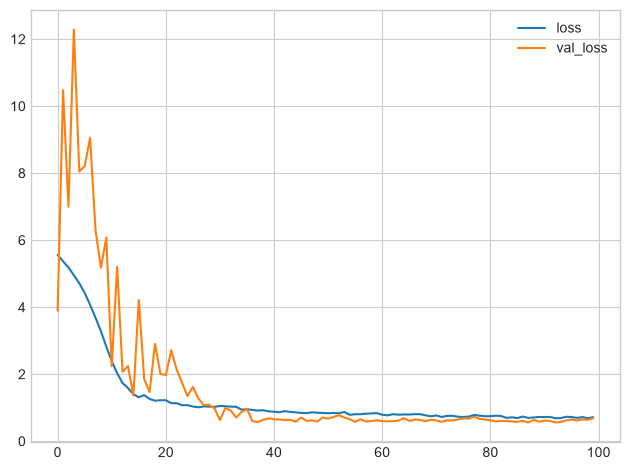

In [3]:
model.compile(
    optimizer='adam',
    loss='mae',
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=256,
    epochs=100,
    verbose=0,
)


# Отображение кривых обучения
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot();

Обычно вы получаете более высокую производительность, если стандартизируете данные перед использованием для обучения. Однако тот факт, что мы вообще смогли использовать необработанные данные, показывает, насколько эффективной может быть пакетная нормализация на более сложных наборах данных.

# Ваша очередь #

Переходите к [**улучшению предсказаний**](https://www.kaggle.com/kernels/fork/11887342) на наборе данных *Spotify* с помощью dropout и посмотрите, как пакетная нормализация может помочь со сложными наборами данных.

---




*Есть вопросы или комментарии? Посетите [форум обсуждения курса](https://www.kaggle.com/learn/intro-to-deep-learning/discussion), чтобы пообщаться с другими учащимися.*